In [1]:
import json
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

import astropy.units as u
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS


In [2]:
sys.path.append(str(Path().resolve() / 'py_modules')) 

import list_maps_plots
import lmc_model

Original Dr. Will Jupyter notebook
https://github.com/will-henney/lvm-turbulence/blob/main/lvm-tarantula-explore-122.ipynb

#  Data

In [3]:
line        = r'H$\alpha$'
lambda_rest = 6562.8
line_id     = 'H'
line_id2   = "6563"

In [4]:
# Data from observations
bins        = 0

region     = 'NGC 2070'
name_reg   = '30 Doradus'
reg_id     = '30Dor'
inst       = 'LVM'
inst_id    = 'LVM'
type_obj   = 'H II region'

pix        = 0   # Instrument resolution [arcsec/pix]
dist       = 50000 # Distance [parsecs]
s0_        = 0.9    # proposed seeing

pc         = dist*(2*np.pi) / (360 * 60 * 60)
s0         = (s0_*pc)

#Since we are working with scatter adata there is no binning that can be applied
name_file    =  inst_id + '-' + reg_id + '-' + line_id2 
name_id      =  inst_id + '-' + reg_id + '-' + line_id2 + '_subrot'
print(name_file)
print(name_id)


LVM-30Dor-6563
LVM-30Dor-6563_subrot


In [5]:
_data = json.load(open('observations/'+ name_file + '-l.json'))
_line = pd.DataFrame(_data['data'])
_line.columns = ['RAdeg', 'DEdeg', 'V_mean','log_F','sigma']


In [6]:
c0 = SkyCoord.from_name("Tarantula")
c0

<SkyCoord (ICRS): (ra, dec) in deg
    (84.675, -69.1)>

In [7]:
fov_deg = 1.0  # Total field of view in degrees (width and height)
pix_scale = 1 / 3600
npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
wcs.wcs.crpix = [npix, npix]  # center of your "image"
wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count

In [8]:
ra0  = c0.ra.deg
dec0 = c0.dec.deg
print(ra0, dec0)

84.675 -69.1


In [9]:
centro = SkyCoord(ra=ra0*u.deg, dec=dec0*u.deg, frame='icrs')

coords = SkyCoord(
    ra=_line["RAdeg"].values * u.deg,
    dec=_line["DEdeg"].values * u.deg,
    frame='icrs'
)

In [10]:
radio = 1239 * u.arcsec   
sep = coords.separation(centro)

line_rad = _line[sep <= radio]

In [11]:
mask = (line_rad["V_mean"] > 220) & (line_rad["V_mean"]<330) \
        & (line_rad["log_F"] > 100) \
        & (line_rad["sigma"] < 1.5) 


In [12]:
df =  line_rad[mask]

In [13]:
c = SkyCoord(ra=df["RAdeg"].to_numpy() * u.deg, dec=df["DEdeg"].to_numpy() * u.deg)
c

<SkyCoord (ICRS): (ra, dec) in deg
    [(84.65      , -69.33053993), (84.67528433, -69.325388  ),
     (84.70055662, -69.32023239), ..., (85.42992956, -69.1498544 ),
     (85.40645637, -69.15584398), (85.38288299, -69.16183337)]>

In [14]:
vmod = lmc_model.vmodel_lmc(c)
vmod

<Quantity [268.43407919, 268.49018305, 268.54637434, ..., 270.35260472,
           270.28978548, 270.22695919] km / s>

In [15]:
df.insert(loc=5,column="v_mod",value=vmod.value,)

In [16]:
col = df.pop('V_mean')
df.insert(4, 'v_', col)

In [17]:
df.insert(loc=2,column="V_mean",value= df.v_-df.v_mod,)

In [18]:
radius_pc = radio.value*pc

In [20]:
name_title = f"30 Dor, central {radius_pc:.0f} pc: " + line
name_title

'30 Dor, central 300 pc: H$\\alpha$'

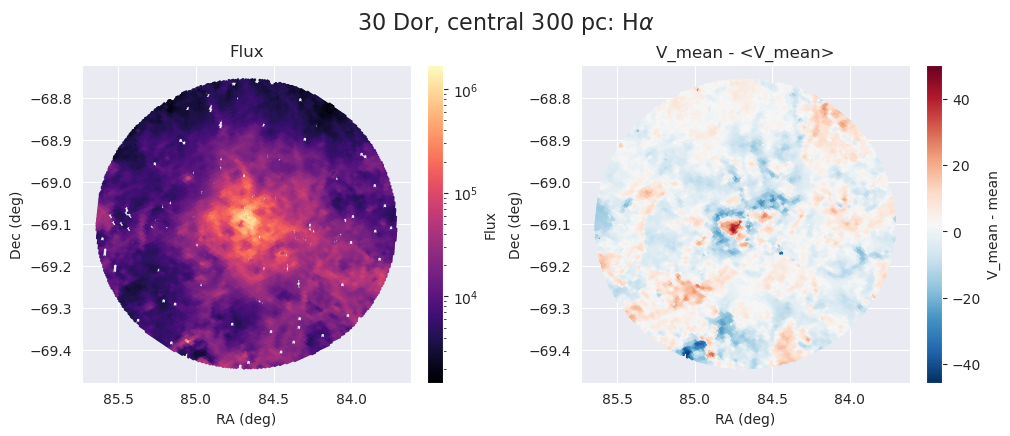

<Figure size 640x480 with 0 Axes>

In [23]:
fig, ax = list_maps_plots.plot_panels_log_title(df,
                                                 s=1.0,
                                                figsize=(10, 4.25),
                                                titles=("Flux", "V_mean - <V_mean>"),
                                                figure_title=name_title)
plt.show()
plt.savefig('Imgs/radii/' + name_title  + '.png', bbox_inches='tight')

In [24]:
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u

def process_radius(_line, coords, centro, lmc_model, radio_arcsec, pc, line,
                   vmin=220, vmax=330, logF_min=100, sigma_max=1.5,
                   save_plot=False, plot_dir="Imgs/radii/"):
    """
    Process one radius:
    - select points inside radius
    - apply mask
    - compute model velocity
    - create corrected V_mean
    - generate title
    - optionally save plot

    Parameters
    ----------
    radio_arcsec : float or int
        Radius in arcsec.
    pc : float
        Conversion factor from arcsec to pc.
    line : str
        Line label used in the title.
    """

    radio = radio_arcsec * u.arcsec
    sep = coords.separation(centro)

    line_rad = _line[sep <= radio].copy()

    mask = (
        (line_rad["V_mean"] > vmin) &
        (line_rad["V_mean"] < vmax) &
        (line_rad["log_F"] > logF_min) &
        (line_rad["sigma"] < sigma_max)
    )

    df = line_rad[mask].copy()

    # Avoid problems if the mask leaves an empty dataframe
    if df.empty:
        return {
            "df": df,
            "radius_arcsec": radio_arcsec,
            "radius_pc": radio_arcsec * pc,
            "title": f"30 Dor, central {radio_arcsec * pc:.0f} pc: {line}",
            "n_points": 0
        }

    c = SkyCoord(
        ra=df["RAdeg"].to_numpy() * u.deg,
        dec=df["DEdeg"].to_numpy() * u.deg
    )

    vmod = lmc_model.vmodel_lmc(c)

    df.insert(loc=5, column="v_mod", value=vmod.value)

    col = df.pop("V_mean")
    df.insert(4, "v_", col)

    df.insert(loc=2, column="V_mean", value=df["v_"] - df["v_mod"])

    radius_pc = radio.value * pc
    name_title = f"30 Dor, central {radius_pc:.0f} pc: {line}"

    if save_plot:
        fig, ax = list_maps_plots.plot_panels_log_title(
            df,
            s=1.0,
            figsize=(10, 4.25),
            titles=("Flux", "V_mean - <V_mean>"),
            figure_title=name_title
        )
        plt.savefig(plot_dir + name_title + ".png", bbox_inches="tight")
        plt.show()

    return {
        "df": df,
        "radius_arcsec": radio_arcsec,
        "radius_pc": radius_pc,
        "title": name_title,
        "n_points": len(df)
    }

In [26]:
radii_arcsec = [103,
                206,
                413,
                826,
                1033,
                1239,
                1652,
                3305]

results_radii = {}


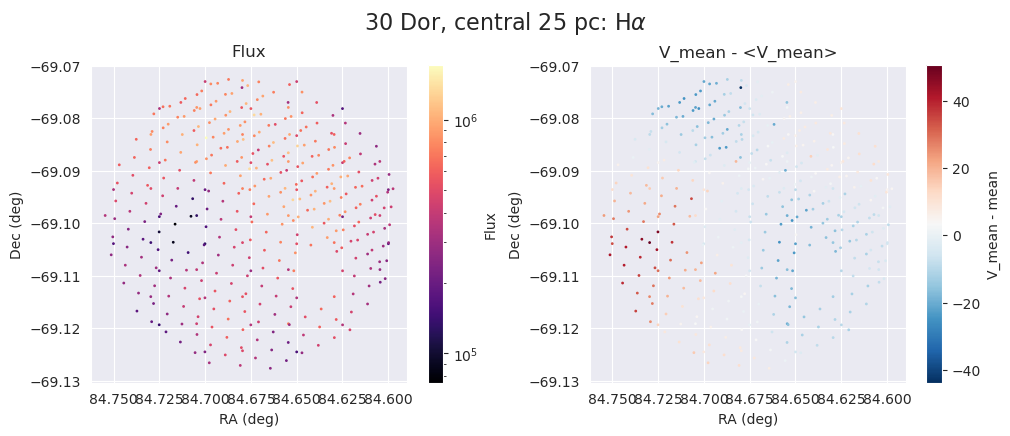

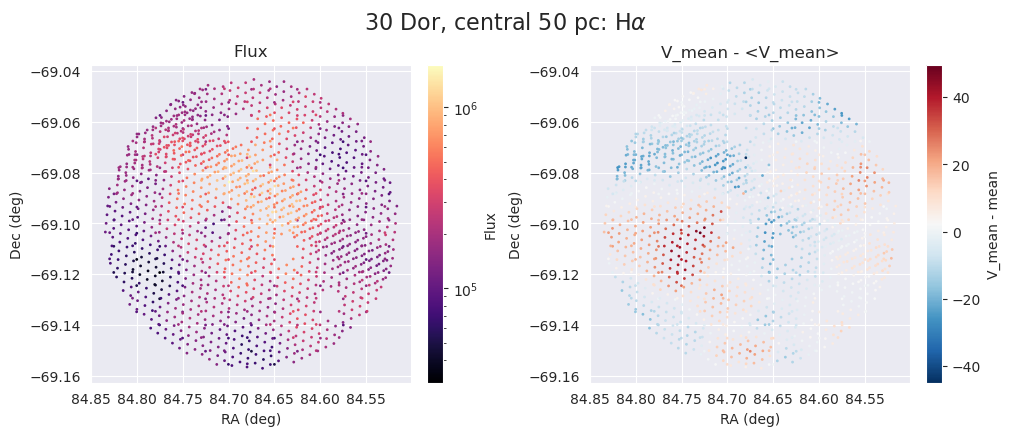

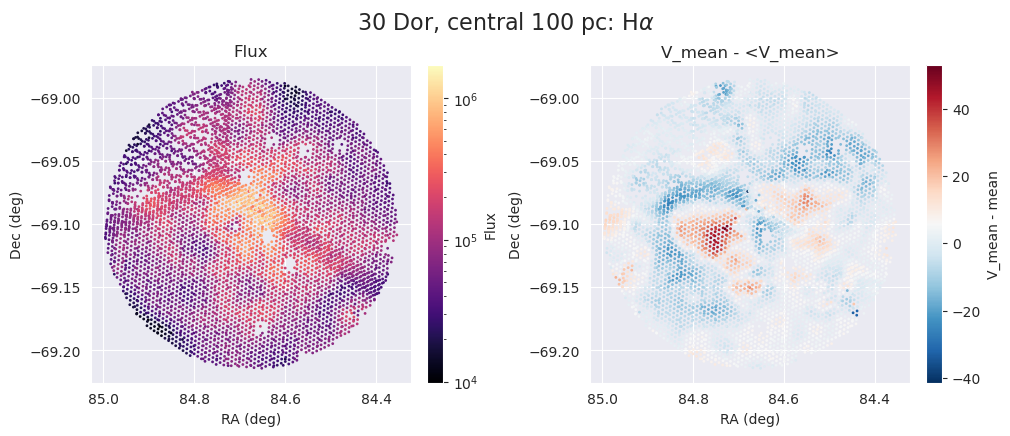

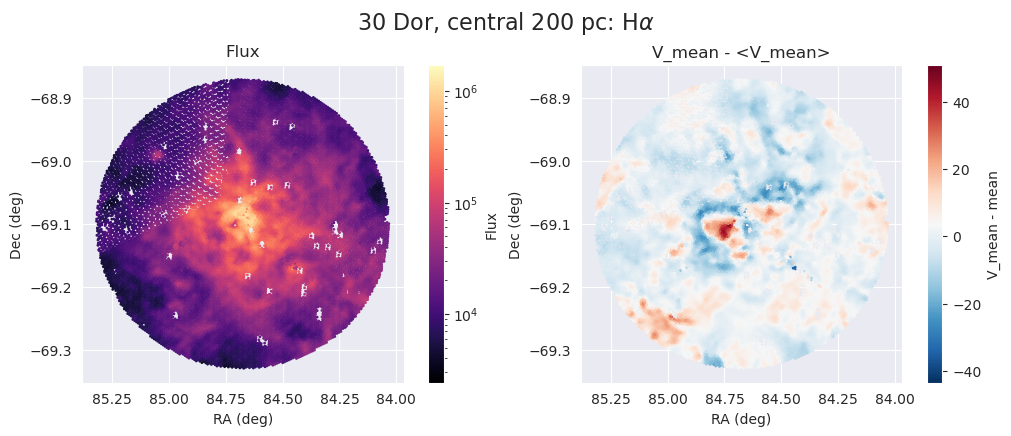

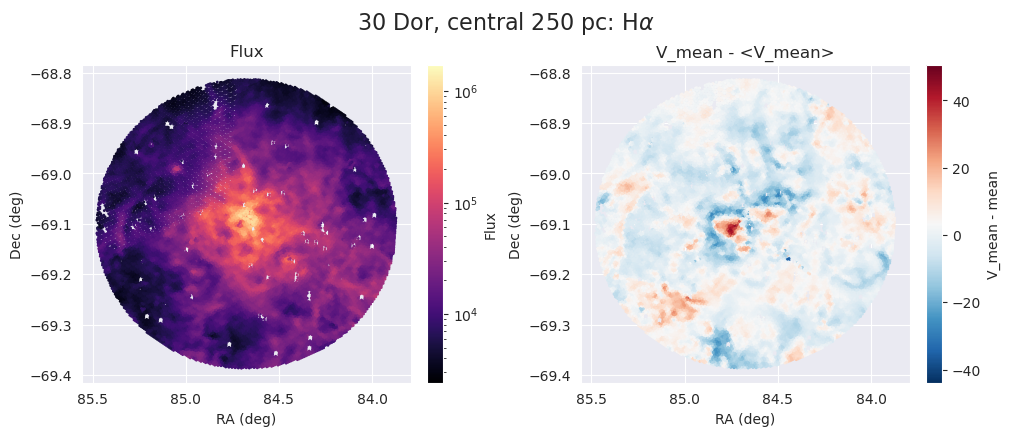

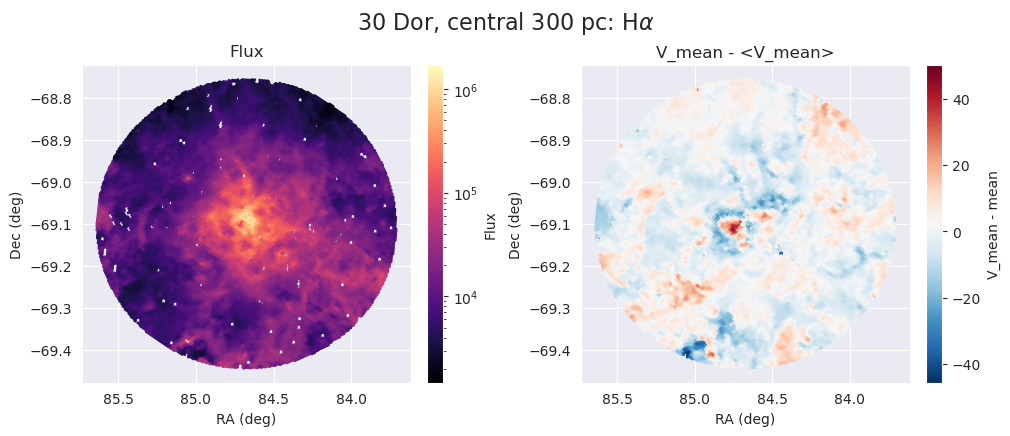

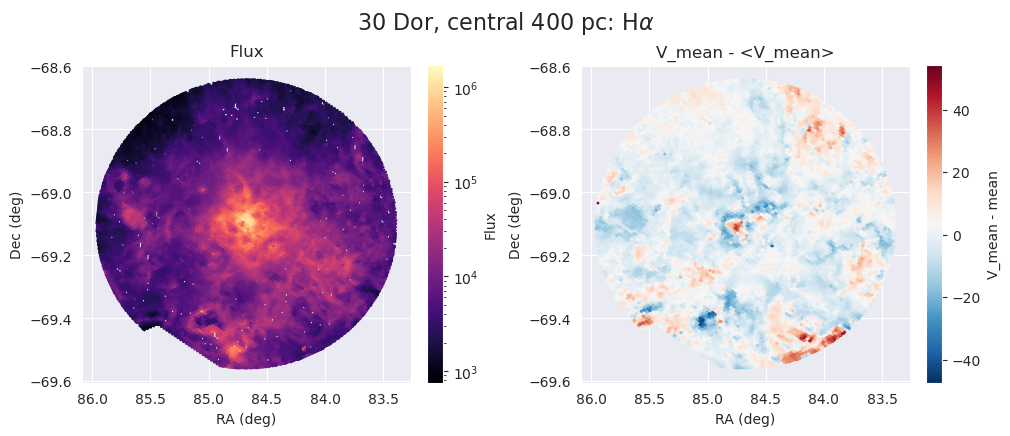

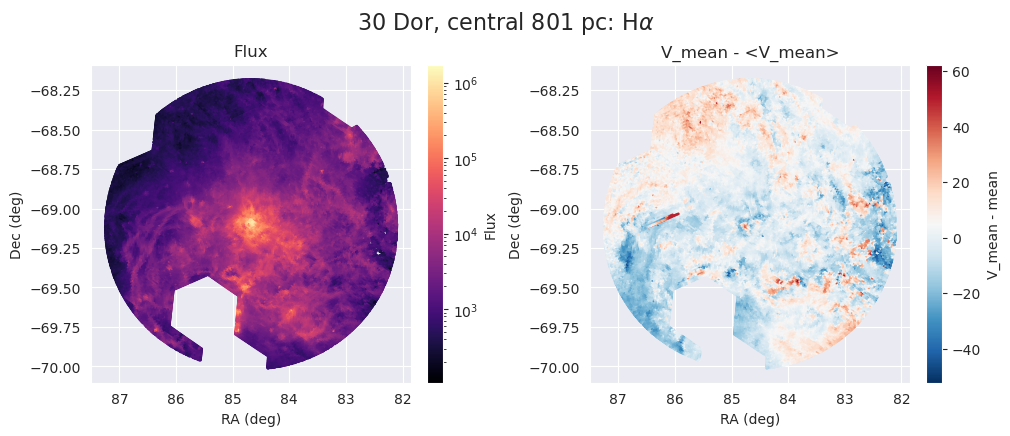

In [27]:
for r in radii_arcsec:
    results_radii[r] = process_radius(
        _line=_line,
        coords=coords,
        centro=centro,
        lmc_model=lmc_model,
        radio_arcsec=r,
        pc=pc,
        line=line,
        save_plot=True
    )

In [38]:
results_radii[103]['df']

,RAdeg,DEdeg,V_mean,log_F,sigma,v_,v_mod
275,84.725051,-69.119368,11.224231,1.397626e+05,1.2809,281.1635,269.939269
276,84.700104,-69.124527,5.524423,2.398311e+05,1.0407,275.4064,269.881977
279,84.650000,-69.124534,-8.430731,1.572660e+05,0.9253,261.4072,269.837931
280,84.675046,-69.119382,-3.363324,3.548621e+05,0.9400,266.5319,269.895224
281,84.700080,-69.114227,5.868226,3.592220e+05,0.9993,275.8208,269.952574
...,...,...,...,...,...,...,...
242030,84.701851,-69.074819,-26.106757,7.291003e+05,0.9206,244.1177,270.224457
242031,84.678262,-69.080710,-10.754075,8.186586e+05,1.1806,259.4091,270.163175
242032,84.654573,-69.086600,-5.684450,1.126133e+06,0.9978,264.4174,270.101850
242033,84.630871,-69.092487,-0.265477,1.022772e+06,0.9713,269.7751,270.040577


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cols_mean = ["V_mean", "log_F", "sigma", "v_"]

rows = []

for r, item in results_radii.items():
    df = item["df"]
    
    row = {
        "radius_arcsec": r,
        "radius_pc": item["radius_pc"]
    }
    
    for col in cols_mean:
        row[col] = df[col].mean() if col in df.columns and not df.empty else np.nan
    
    rows.append(row)

df_means = pd.DataFrame(rows).sort_values("radius_arcsec").reset_index(drop=True)

df_means

,radius_arcsec,radius_pc,V_mean,log_F,sigma,v_
0,103,24.967905,-2.840549,566291.087281,0.962589,267.202122
1,206,49.935809,-1.774470,293671.750678,0.915946,268.274710
2,413,100.114025,-5.235732,144337.746957,0.862525,264.811290
3,826,200.228050,-3.134597,53925.418008,0.812566,266.925487
4,1033,250.406266,-2.763144,40242.444958,0.808346,267.299646
5,1239,300.342075,-2.517466,32334.093198,0.805875,267.552788
6,1652,400.456101,-0.880906,22655.910739,0.814693,269.200053
7,3305,801.154608,0.165502,9276.494051,0.841440,270.401268


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cols_mean = ["V_mean", "log_F", "sigma", "v_"]

rows = []

for r, item in results_radii.items():
    df = item["df"]
    
    row = {
        "radius_arcsec": r,
        "radius_pc": item["radius_pc"]
    }
    
    for col in cols_mean:
        row[col] = df[col].std() if col in df.columns and not df.empty else np.nan
    
    rows.append(row)

df_std = pd.DataFrame(rows).sort_values("radius_arcsec").reset_index(drop=True)

df_std

,radius_arcsec,radius_pc,V_mean,log_F,sigma,v_
0,103,24.967905,15.373489,269966.380110,0.148929,15.365561
1,206,49.935809,13.790491,231574.263774,0.123685,13.724390
2,413,100.114025,9.903468,156070.400638,0.106625,9.827619
3,826,200.228050,7.145117,97156.547865,0.085449,6.994087
4,1033,250.406266,6.812382,82469.471306,0.083303,6.844259
5,1239,300.342075,6.920832,71584.104427,0.086953,7.071419
6,1652,400.456101,8.020425,57462.034591,0.101636,8.179220
7,3305,801.154608,11.138730,34076.942120,0.129093,12.448334


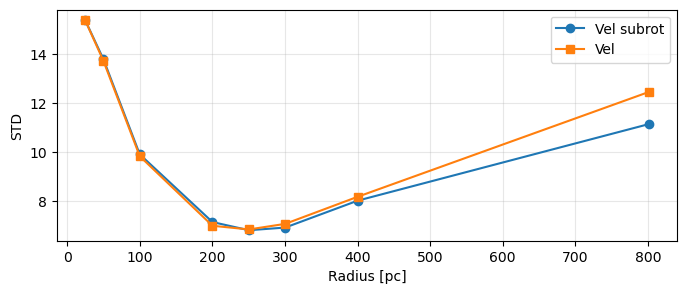

In [68]:
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(df_std["radius_pc"], df_std['V_mean'], marker="o", label='Vel subrot')
ax.plot(df_std["radius_pc"], df_std['v_'], marker="s", label='Vel')

ax.set_xlabel("Radius [pc]")
ax.set_ylabel("STD")
#ax.set_title("Mean column values vs radius")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

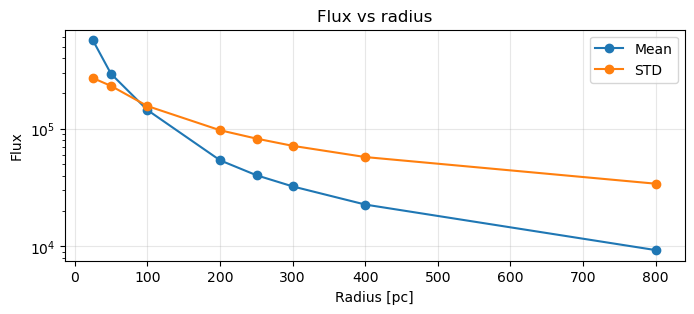

In [69]:
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(df_means["radius_pc"], df_means['log_F'], marker="o", label = 'Mean')
ax.plot(df_std["radius_pc"], df_std['log_F'], marker="o", label='STD')

ax.set_xlabel("Radius [pc]")
ax.set_ylabel("Flux")
ax.set_title("Flux vs radius")
ax.legend()
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.show()

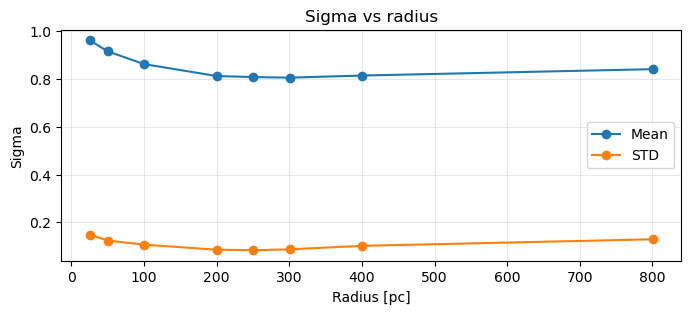

In [70]:
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(df_means["radius_pc"], df_means['sigma'], marker="o", label = 'Mean')
ax.plot(df_std["radius_pc"], df_std['sigma'], marker="o", label='STD')

ax.set_xlabel("Radius [pc]")
ax.set_ylabel("Sigma")
ax.set_title("Sigma vs radius")
ax.legend()
#ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.show()

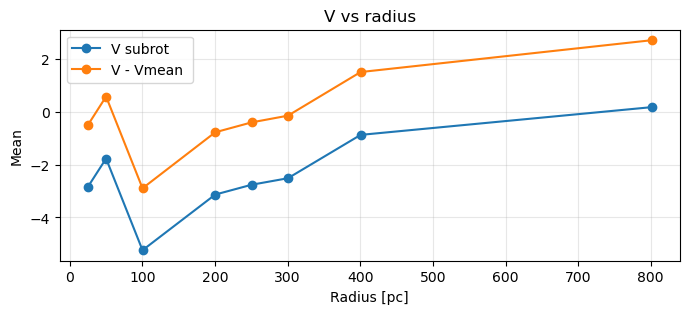

In [82]:
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(df_means["radius_pc"], df_means['V_mean'], marker="o", label = 'V subrot')
ax.plot(df_means["radius_pc"], df_means['v_']-df_means['v_'].mean(), marker="o", label = 'V - Vmean ')
#ax.plot(df_std["radius_pc"], df_std['sigma'], marker="o", label='STD')

ax.set_xlabel("Radius [pc]")
ax.set_ylabel("Mean")
ax.set_title("V vs radius")
ax.legend()
#ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.show()